# Iterative Retrieval

## Definition

Iterative retrieval is a retrieval strategy in which a system searches for information in multiple rounds instead of relying on a single query and retrieval step. After each round, the system evaluates the retrieved content, identifies missing or unclear information, refines the query, and performs another search.

This process allows the retriever to progressively improve the evidence used to answer a complex question. It is especially useful in retrieval-augmented generation (RAG), where the first set of documents may not contain all the context required for a reliable answer.

## Typical Process

1. **Start with the original question:** Analyze the user's intent and create an initial search query.
2. **Retrieve relevant documents:** Search the knowledge base or external sources.
3. **Evaluate the evidence:** Check whether the retrieved information is relevant, complete, and sufficiently specific.
4. **Refine the query:** Identify unanswered parts, ambiguities, or missing entities.
5. **Retrieve again:** Search using the refined query and combine the new evidence with previous results.
6. **Generate the answer:** Stop when enough reliable information has been collected and synthesize the final response.

## Example

For the question:

> What caused a model's performance to decline after deployment, and how can it be improved?

The first retrieval round may find information about performance decline. A later round can use those results to search specifically for deployment drift, data quality issues, monitoring methods, and possible improvements.

Iterative retrieval improves recall and supports multi-step reasoning, but it should use a stopping condition to avoid unnecessary searches, repeated evidence, and increased latency.


In [1]:
import os

os.environ["USER_AGENT"] = "UjjalLangChainApp/1.0 (Language=Python)"

from typing import List
from pydantic import BaseModel
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document



/var/folders/6c/rlq9mq415gbd8q7dxvzdt3zr0000gn/T/ipykernel_85608/763510430.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader, TextLoader


In [2]:
##Laod Environment
load_dotenv()

## set up the environment
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Initiate model
llm=init_chat_model("openai:gpt-4o")

In [3]:
## Step 1 - Vectorstore
urls = [
    "https://lilianweng.github.io/posts/2026-07-04-harness/",
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs=[]
for loader in loaders:
    docs.extend(loader.load())
textSpliters = RecursiveCharacterTextSplitter(separators=["", " ", "\n", "\n\n"], chunk_size=200, chunk_overlap=50, length_function=len)
chunk = textSpliters.split_documents(docs)
embeddings = OpenAIEmbeddings()
vectorStore = FAISS.from_documents(chunk, embeddings)
retriever_faiss = vectorStore.as_retriever()

In [4]:
## Step 2 - Defining Langgraph State

class IterativeRetrievalState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""
    refined_question: str = ""
    verified: bool = False
    attempts: int = 0

In [5]:
## Step 3 - Nodes creation

# ab. Retrieve Node
def retrieve_docs(state: IterativeRetrievalState) -> IterativeRetrievalState:
    docs = retriever_faiss.invoke(state.refined_question or state.question)

    return state.model_copy(update={"retrieved_docs": docs})

# c. Generate Answer Node
def generate_answer(state: IterativeRetrievalState) -> IterativeRetrievalState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
    Use the following context to answer the question:

    Context:
    {context}

    Question:
    {state.question}
    """

    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

# c. Self-Reflect
def reflect_on_answer(state: IterativeRetrievalState) -> IterativeRetrievalState:
    prompt = f"""
    Reflect on the following answer to see if it fully address the question.
    state YES if it is a complete and correct, or NO with an explanation.

    Question:
    {state.question}

    Answer:
    {state.answer}

    Respond like:
    Reflection: YES or NO
    Explanation: ...
    """

    result = llm.invoke(prompt).content
    is_revised = "reflection: no" in result.lower()
    return state.model_copy(update={"verified": is_revised})


In [6]:

# c. Refined query
def refined_query(state: IterativeRetrievalState) -> IterativeRetrievalState:
    prompt = f"""
    Refine the following question to make it more specific and answerable:

    Original Question:
    {state.question}
    Current Answer:
    {state.answer}
    """

    refined_question = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question": refined_question})

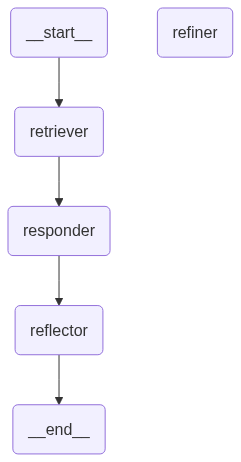

In [10]:
## Step 4 - Building Langgraph Graph

from langgraph.graph import END, START, StateGraph


builder=StateGraph(IterativeRetrievalState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("refiner", refined_query)

# =========
# builder.add_edge(START, "planner")
# == OR ===
builder.set_entry_point("retriever")
# =========
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")

builder.add_conditional_edges(
    "reflector",
    lambda s: END if not s.verified or s.attempts >= 2 else "refiner"
)
builder.add_edge("refiner", "retriever")

graph = builder.compile()
graph

In [12]:
## Step 5 - Run the Agent

if __name__ == "__main__":
    query = "How File System as Persistent Memory work?"
    state = IterativeRetrievalState(question=query)
    final_result = graph.invoke(state)

    print("\n No of Attempts:", final_result["attempts"])
    print("\n Reflection Log:", final_result["refined_question"])
    print("\n Final Answer:", final_result["answer"])


 No of Attempts: 2

 Reflection Log: Refined Question:
How does using a file system as persistent memory facilitate data management and recovery in long-horizon agent systems, specifically in the context of large language models (LLMs)?

Refined Answer:
Using a file system as persistent memory enhances data management and recovery processes in long-horizon agent systems by leveraging the file system to store and retrieve data, states, and artifacts persistently. This approach relies on reading, writing, and editing files, which often involve using bash commands or similar methods. This allows large language models (LLMs) to maintain control over complex states and artifacts beyond their immediate context window. By storing crucial information in the form of files, logs, and status records, the system can effectively manage operations that last longer than the model’s memory constraints. Even in the event of interruptions, the persistent nature of the file system ensures continuity and